## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [35]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'
filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_y1985.1y_gridT.nc'
filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979_0000.nc'

# NEMO full grid coords
filepath_domain_cfg = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Set the filepaths 
# The target grid mask 
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
# The target grid geometry
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
folder_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM001' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 
filepath_nn_output = folder_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = False

## Apply neural network

In [3]:
import time

In [4]:
%%time
apply_nn_to_NEMO(filepath_nemo_output, 
                     filepath_mask, 
                     filepath_geomvars, 
                     filepath_eORCA1_bmach_masks, 
                     path_model, 
                     path_norm_metrics, 
                     filepath_nn_output, 
                     this_collection, 
                     exp_name, 
                     join_ice_shelves, 
                     verbose = 0)

You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc
You have loaded coordinates: /bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979_0000.nc
Cropped to Antarctica only
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979_0000.nc
Cropped to Antarctica only
Loaded data. Time: 4.7 s
There are 0 basins with no ocean profiles : []
There should be 5 basins (2 with no cavities plus 3 where we merged)
Created T/S profiles. Time: 12.0 s
Prepared data to apply NN. Time: 16.1 s
Applying neural networks
Applied NN. Time: 23.7 s               
You have loaded: /bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979_0000.nc
Cropped to Antarctica only
Returning area
Putting melt back onto the ocean grid
Propagated melt to ocean cells. Time: 24.6 s
You have saved the nn output to: /bettik/ockendeh/SCRIPTS/simpleNN_bas

## Look at the resulting melt distribution map for NEMO

/tmp/ipykernel_957044/1377218014.py:6: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
/tmp/ipykernel_957044/1377218014.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_957044/1377218014.py:11: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
/tmp/ipykernel_957044/1377218014.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


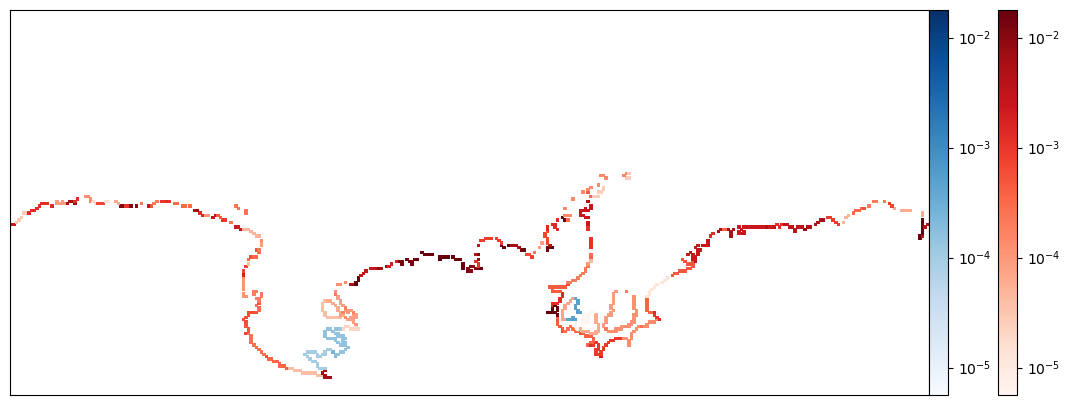

In [11]:
melt = xr.open_dataset(filepath_nn_output)# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
#ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')

In [ ]:
purple

# A more in depth look at what is happening in the apply_nn_to_NEMO function

### Load in the NEMO data, masks associated, and the target grid for the NN

In [12]:
# Load in the TS grid 
gridT2 = load_TSmelt_normal(filepath_nemo_output)
# Load in the mask for the ocean region 
bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
mask_nocavs = bmach_masks.mask_nocavs.values
bmach_masks.close()

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
# Rename the dimensions of basins merged to be x and y 
if 'y_grid_T' in basins_merged.dims:
    basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# The basins mask for the NEMO 025 grid  
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')
basin_nos = np.unique(basins_NEMO)

You have loaded T and S: /bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979_0000.nc
Cropped to Antarctica only
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc
You have loaded coordinates: /bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979_0000.nc
Cropped to Antarctica only


In [13]:
basin_nos

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133.])

### Create a list of the cells where it is okay to extract ocean profiles 

In [14]:
# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where((mask_nocavs == 1))
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)

In [15]:
# Making a note to compare the new and old basins for basin 35/36

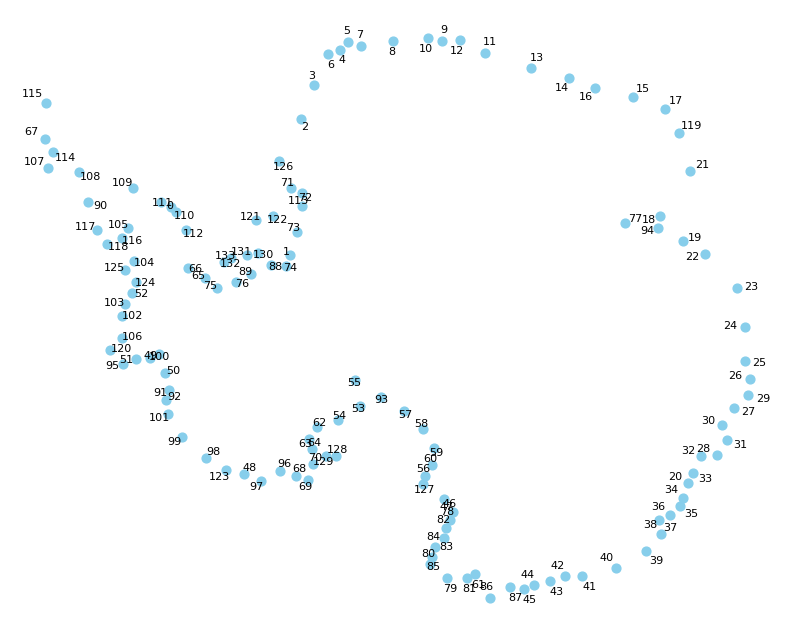

In [16]:
plot_basin_nos_map = True
if plot_basin_nos_map == True:
    fig, ax = plt.subplots(1,1, figsize = (10,8))
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        if len(x_cavs) > 0:
            plt.scatter(np.mean(x_cavs), np.mean(y_cavs), s = 40, c = 'skyblue')
        if np.mod(i,2) == 1: 
            plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*1.04, np.mean(y_cavs)*1.04), fontsize = 8, ha = 'center', va = 'center')
        else:
          plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*0.96, np.mean(y_cavs)*0.96), fontsize = 8, ha = 'center', va = 'center')  
    ax.axis('off');

In [17]:
# To look at which ocean cells are extracted for each individual basin
plot_figure = False
if plot_figure == True:
    #kk = 100
    #i = basin_nos[kk]
    #i = 104 #(A good example where it comes around the corner)
    i = 125 ## AAAAh George VI
    i = 24
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    ocean_edge_illus = np.zeros_like(mask_nocavs)
    # If you allow all the nearest cells
    # And fill the cells found with the kd-tree
    for k in range(len(idx)):
        ocean_edge_illus[iy[idx[k]], ix[idx[k]]] = 1

    # Only allow cells where the distance is less than 1.5 times the minimum distance 
    # Should allow cells which are adjacent or as close to adjacent as possible
    idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
    for k in range(len(idxn)):
        ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    
    # Convert to polar stereographic coordinates 
    coords_x, coords_y = transformer.transform(coords.nav_lat, coords.nav_lon)
    # Calculate mean and range of cavity points
    mean_xcavs, mean_ycavs = np.mean(x_cavs), np.mean(y_cavs)
    rang_xcavs, rang_ycavs = np.max(x_cavs) - np.min(x_cavs), np.max(y_cavs) - np.min(y_cavs)
    rang = np.max((rang_xcavs, rang_ycavs))
    if rang < 500000:
        rang = 500000
    # Create mask of the relevant region)
    mask_close = (coords_x < (np.max(x_cavs) + rang*0.3)) & (coords_x > (np.min(x_cavs) - rang*0.3)) & \
                 (coords_y < (np.max(y_cavs) + rang*0.3)) & (coords_y > (np.min(y_cavs) - rang*0.3)) 
    
    # Ocean cells 
    iy2, ix2 = np.where(ocean_edge_basin == 1)
    x_oceanhere = []
    y_oceanhere = []
    for jkl in (0,1,2,3,0):
        lat_oceanhere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy2, ix2]
        lon_oceanhere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy2, ix2]
        x_jkl, y_jkl = transformer.transform(lat_oceanhere, lon_oceanhere)
        x_oceanhere.append(x_jkl)
        y_oceanhere.append(y_jkl)
    # Ocean cells with old code  
    iy5, ix5 = np.where(ocean_edge_illus == 1)
    x_illushere = []
    y_illushere = []
    for jkl in (0,1,2,3,0):
        lat_illushere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy5, ix5]
        lon_illushere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy5, ix5]
        x_jkl, y_jkl = transformer.transform(lat_illushere, lon_illushere)
        x_illushere.append(x_jkl)
        y_illushere.append(y_jkl)
    
    # All Bedmachine cells 
    iy3, ix3 = np.where((mask_close == 1) & (mask_nocavs == 1)) 
    x_grid = []
    y_grid = []
    for jkl in (0,1,2,3,0):
        lat_here = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy3, ix3]
        lon_here = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy3, ix3]
        x_jkl, y_jkl = transformer.transform(lat_here, lon_here)
        x_grid.append(x_jkl)
        y_grid.append(y_jkl)
    
    # Load in the bedmachine data for plotting
    # Filepath_bedmachine 
    filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
    
    fig, axs = plt.subplots(1,2, figsize = (11,7), width_ratios = (2.5,1))
    plt.subplots_adjust(wspace = 0)
    
    ax = axs[0]
    ax.fill(x_oceanhere, y_oceanhere, c = 'lightpink', zorder = 2, alpha = 0.5);
    ax.fill(x_illushere, y_illushere, c = 'hotpink', zorder = 1, alpha = 0.5);
    ax.plot(x_grid, y_grid, c = 'k', linewidth = 0.1, zorder = 10, alpha = 0.5);
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    value = 2
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'lightgrey', \
              label = '', zorder = 0, alpha = 0.5)
    value = 0
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'paleturquoise', \
              label = 'Ocean', zorder = 0, alpha = 0.5)
    #ax.axis('equal')
    ax.set_xlim(np.min(x_cavs)-rang*0.2, np.max(x_cavs) + rang*0.2)
    ax.set_ylim(np.min(y_cavs)-rang*0.2, np.max(y_cavs) + rang*0.2)
    
    ax.scatter(x_cavs, y_cavs, zorder = 10)
    ax.set_xticks([]), ax.set_yticks([])
    
    ax = axs[1]
    ax.scatter(x_cavs, y_cavs, s = 0.05)
    ax.plot((np.min(x_cavs) - rang*0.2, np.min(x_cavs) - rang*0.2, \
             np.max(x_cavs) + rang*0.2, np.max(x_cavs) + rang*0.2, \
             np.min(x_cavs) - rang*0.2), \
            (np.min(y_cavs) - rang*0.2, \
             np.max(y_cavs) + rang*0.2, np.max(y_cavs) + rang*0.2, \
             np.min(y_cavs) - rang*0.2, np.min(y_cavs) - rang*0.2), c = 'red')
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.05, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    ax.axis('equal')
    ax.set_xticks([]), ax.set_yticks([])
    ax.axis('off')
    
    fig.savefig('FIGURES/howtoselectoceancells.jpg', dpi = 200, bbox_inches = 'tight')

In [18]:
# For each basin in basin_nos, create a mask of the ocean profiles to extract 
profiles_all = []
i_no_value = []
basins_all_temp = np.zeros_like(mask_nocavs)
for kk in range(len(basin_nos)):
    i = basin_nos[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 1.5])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    else:
        # Calculate which basins don't have profiles
        i_no_value.append(int(i))
    ### This is only needed if you want to look at which ocean cells will recieve melt from many basins   
    basins_all_temp = basins_all_temp + ocean_edge_basin
   
    # Use the mask to extract the relevant profiles 
    masked_depth = gridT2.where(ocean_edge_basin == 1)
    profiles = masked_depth.stack(points=("x", "y"))
    profiles = profiles.dropna(dim="points", how="all")
    #profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
    # Fill the nan values in the profile
    profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
    # Add a coordinate for kk
    profile_kk = profile_kk.expand_dims(kk =[int(i)])
    #profile_kk = profile_kk.expand_dims(kk_m1 =[int(i)-1])
    profiles_all.append(profile_kk)
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')
# Concatenate the profiles along the new dimension
all_profiles = xr.concat(profiles_all, dim="kk")

print('There are {} basins with no ocean profiles : {}'.format(len(i_no_value), i_no_value))
#print('There should be 17 basins (14 with no cavities plus 3 where we merged)')

There are 0 basins with no ocean profiles : []


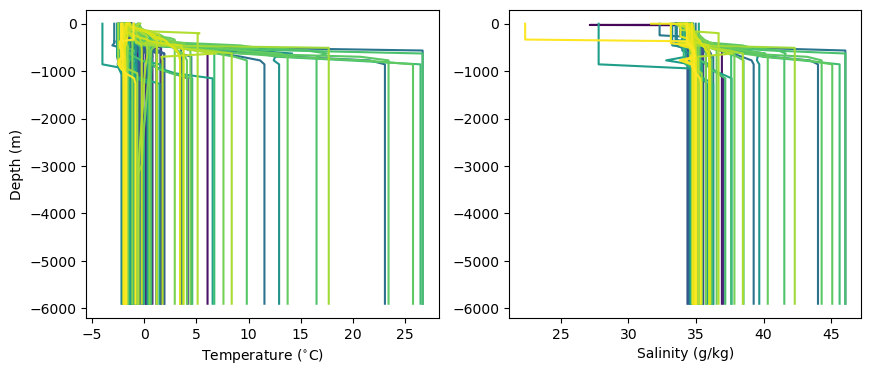

In [19]:
plot_profile = True
if plot_profile == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
    ax[0].set_ylabel('Depth (m)');
    #ax[1].set_ylabel('Depth (m)')
    ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
    ax[1].set_xlabel('Salinity (g/kg)');
fig.savefig('profile.jpg', dpi = 200, bbox_inches = 'tight')

In [20]:
# Extract the relevant values of temperature and salinity 
temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
temp_xy = temp_xy.reset_coords(drop=True)
sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
sals_xy = sals_xy.reset_coords(drop=True)

# Calculate mean and standard deviation by region
# Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
meanT_by_region = temp_xy.groupby(basins_merged).mean()
stdT_by_region  = temp_xy.groupby(basins_merged).std()
meanS_by_region = sals_xy.groupby(basins_merged).mean()
stdS_by_region  = sals_xy.groupby(basins_merged).std()
# and send back to the original grid 
mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
std_S = stdS_by_region.sel(basins_NEMO = basins_merged)
# Reset the coordinates
mean_T = mean_T.reset_coords(drop=True)
mean_S = mean_S.reset_coords(drop=True)
std_T = std_T.reset_coords(drop=True)
std_S = std_S.reset_coords(drop=True)

/tmp/ipykernel_957044/3945807193.py:14: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)


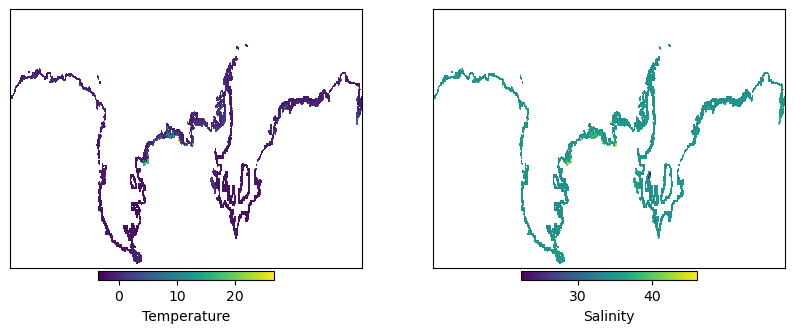

In [21]:
plot_figure = True
if plot_figure == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    #closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    closed_cavs = masks.closed_cavities_nan#.rename({"y_grid_T": "y", "x_grid_T": "x"})
    im = [[],[]]
    # Note that using pcolor rather than pcolormesh leads to the error
    im[0] = ax[0].pcolor(temp_xy*closed_cavs)
    im[1] = ax[1].pcolor(sals_xy*closed_cavs)
    labels = 'Temperature', 'Salinity'
    for i in range(2):
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)
        cbar.set_label(labels[i])
fig.savefig('Propagated.jpg',dpi= 200, bbox_inches = 'tight')

In [22]:
# Create the input dataset for the neural network to be applied to
ds = geoms.rename({"areas": "area",
                   "isf_draft": "corrected_isdraft",
                   "slope_isdraft_lon": "slope_is_lon",
                   "slope_isdraft_lat": "slope_is_lat",
                   "slope_bathy_lon": "slope_ba_lon",
                   "slope_bathy_lat": "slope_ba_lat",})
ds = ds.assign(temperature_prop = temp_xy,
                  mean_T           = mean_T,
                  std_T            = std_T,
                  salinity_prop    = sals_xy,
                  mean_S           = mean_S,
                  std_S            = std_S,
                  basins_NEMO      = basins_merged,)
ds.attrs["description"] = "Neural network input variables"

In [53]:
# Rename variables in closed cavity mask 
if 'y_grid_T' in basins_merged.dims:
    closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
else:
    closed_cavs = masks.closed_cavities_nan
# Select only the points in the closed cavity regions
stacked = ds.where(closed_cavs == 1).stack(points=("x", "y")).dropna("points", how = "all")
# and convert to a pandas dataframe
selected = stacked.to_dataframe().reset_index().drop(columns=["x", "y"])

# Remove nan values (although still unclear why there are nan values)
selected = selected[~np.isnan(selected.temperature_prop)]


# Apply all 10 neural networks 
print('Applying neural networks')
melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)
areas = load_area(filepath_nemo_output)
melt_all = np.zeros_like(mask_nocavs)
melt_b = np.zeros_like(mask_nocavs)
melt_t = np.zeros_like(mask_nocavs)
print('Putting melt back onto the ocean grid')
for kk in range(len(melt_by_basin.basin)):
    i = melt_by_basin.basin[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Calculate the top and bottom depths to inject the melt 
    # Currently using means, but might be better to use a min/max? ideally at cells touching the ocean 
    melt_b_basin = np.mean(geoms.bathymetry.values[mask_basin_cavs == 1])
    melt_t_basin = np.mean(geoms.isf_draft.values[mask_basin_cavs == 1])
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    # Redistribute the melt over the relevant cells
    # Number of pixels?
    #pixels = np.sum(ocean_edge_basin)
    # Total area covered 
    ocean_area = np.sum(areas * ocean_edge_basin).data
    # Melt per pixel?? 
    melt_per_pixel = melt_by_basin.melt_Gt[kk] * (10e12/(60*60*24*365.5)) /ocean_area
    ocean_melt = ocean_edge_basin * melt_per_pixel
    # Apply top and bottom over the relevant cells
    ocean_melt_b = ocean_edge_basin * melt_b_basin
    ocean_melt_t = ocean_edge_basin * melt_t_basin
    # Sum up the melt over all the basins
    melt_all = melt_all + ocean_melt
    melt_b = melt_b + ocean_melt_b
    melt_t = melt_t + ocean_melt_t
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')

Applying neural networks
You have loaded: /bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979_0000.nc
Cropped to Antarctica only
Returning area
Putting melt back onto the ocean grid


In [61]:
# Put back onto the original grid from the input file
gridT_varofint = xr.open_dataset(filepath_nemo_output)[['x','y']]
min_lat = -52.2
y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
melt_t2   = expand_to_full_grid(melt_t,    y_trim, gridT_varofint)
melt_b2   = expand_to_full_grid(melt_b,    y_trim, gridT_varofint)
melt_all2 = expand_to_full_grid(melt_all,  y_trim, gridT_varofint)

In [77]:
# And then put back onto the full eORCA1 grid 
lat_full = domain_cfg.nav_lat[:, 0].data
lat_sub  = melt_t2.nav_lat[:, 0].data
y0 = np.where(lat_full == lat_sub[0])[0][0]
full_t = np.full(domain_cfg.nav_lat.shape, np.nan)
Ny_sub = melt_t2.shape[0]
full_t[y0:y0 + Ny_sub, :] = melt_t2.data

lat_full = domain_cfg.nav_lat[:, 0].data
lat_sub  = melt_t2.nav_lat[:, 0].data

# Find the matching starting latitude
y_trim2 = int(np.argmin(np.abs(lat_full - lat_sub[0])))
y0 = np.where(lat_full == lat_sub[0])[0][0]
print(y_trim2, y0)

0 0


In [81]:
print(lat_sub[0:5])
print(lat_full[0:20])


[-84.21071  -84.108955 -84.005424 -83.90008  -83.79289 ]
[-84.21071  -84.108955 -84.005424 -83.90008  -83.79289  -83.68382
 -83.572845 -83.45993  -83.34504  -83.22814  -83.1092   -82.988174
 -82.865036 -82.739746 -82.612274 -82.48257  -82.3506   -82.21633
 -82.07972  -81.94073 ]


In [79]:
full_t = expand_to_full_grid(melt_t2, 165, domain_cfg)

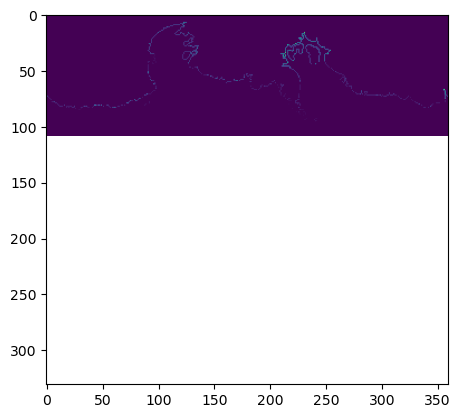

In [91]:
plt.imshow(full_t)

In [ ]:
gridT_varofint = xr.open_dataset(filepath_nemo_output)[['x','y']]
min_lat = -52.2
y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
full_t   = expand_to_full_grid(melt_t,    y_trim, gridT_varofint)
full_b   = expand_to_full_grid(melt_b,    y_trim, gridT_varofint)
full_all = expand_to_full_grid(melt_all,  y_trim, gridT_varofint)

In [49]:
# Expanding the grid back to the NEMO eORCA1 grid 
domain_cfg = xr.open_dataset(filepath_domain_cfg)[['nav_lat','nav_lon']]
min_lat = -52.2
lat = domain_cfg.nav_lat[:, 0].data
y_trim = np.where(lat >= min_lat)[0][0]
#y_trim = np.max(np.argwhere(domain_cfg.nav_lat[:,0].data <= min_lat))
full_t = np.full(domain_cfg.nav_lat.shape, 0)
full_t[y_trim:y_trim + melt_t.shape[0], :] = melt_t

#full_t   = expand_to_full_grid(melt_t,    y_trim, domain_cfg)
#full_b   = expand_to_full_grid(melt_b,    y_trim, domain_cfg)
#full_all = expand_to_full_grid(melt_all,  y_trim, domain_cfg)

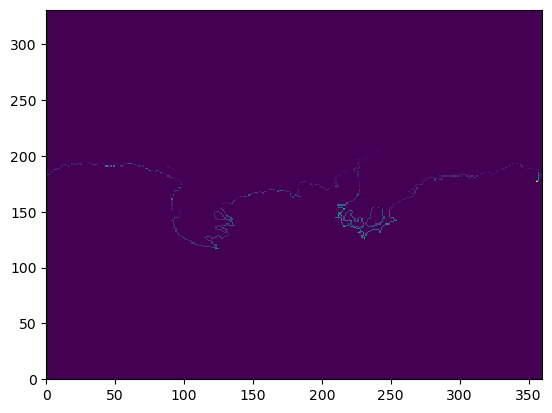

In [51]:
plt.pcolor(full_t)

In [32]:
# Create a netcdf dataset for the temperature and salinity profiles 
output_melt = xr.Dataset(data_vars=dict(
                                melt      = (["y", "x"], full_all.data), 
                                melt_top  = (["y", "x"], full_t.data),
                                melt_base = (["y", "x"], full_b.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), full_all.nav_lon.data),
                               lat = (("y", "x"), full_all.nav_lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network output", 
                               simulation_run = simulation, 
                               year           = year_of_interest, 
                               history        = f"{time.ctime()}: Applied neural network"),
                        )     

output_melt = output_melt.fillna(0)
print('Nan values filled')

output_melt["melt"].attrs.update({"standard_name": "Sub-shelf melt for parameterised regions",
                                  "units": "kg m-2 s-1"})
output_melt["melt_top"].attrs.update({"standard_name": "Top level to inject melt",
                                     "units": "m"})
output_melt["melt_base"].attrs.update({"standard_name": "Bottom level to inject melt",
                                     "units": "m"})
output_melt["lat"].attrs.update({"standard_name": "Latitude",
                                 "units": "degrees_north"})
output_melt["lon"].attrs.update({"standard_name": "Longitude",
                                 "units": "degrees_east"})

# Export to netcdf 
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

filepath_this_nn_output = filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'
output_melt.to_netcdf(filepath_this_nn_output)
print('You have saved the nn output to:', filepath_this_nn_output)

Nan values filled
You have saved the nn output to: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_output_melt_DUM001_9999.ncnn_output_melt_DUM002_9999.nc


In [33]:
output_melt.melt

<xarray.DataArray 'melt' (y: 166, x: 360)> Size: 478kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
    lon      (y, x) float32 239kB 73.5 74.5 75.5 76.5 ... 69.5 70.5 71.5 72.5
    lat      (y, x) float32 239kB -84.21 -84.21 -84.21 ... -7.917 -7.917 -7.917
Dimensions without coordinates: y, x
Attributes:
    standard_name:  Sub-shelf melt for parameterised regions
    units:          kg m-2 s-1

/tmp/ipykernel_957044/3407234724.py:6: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
/tmp/ipykernel_957044/3407234724.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_957044/3407234724.py:11: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
/tmp/ipykernel_957044/3407234724.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


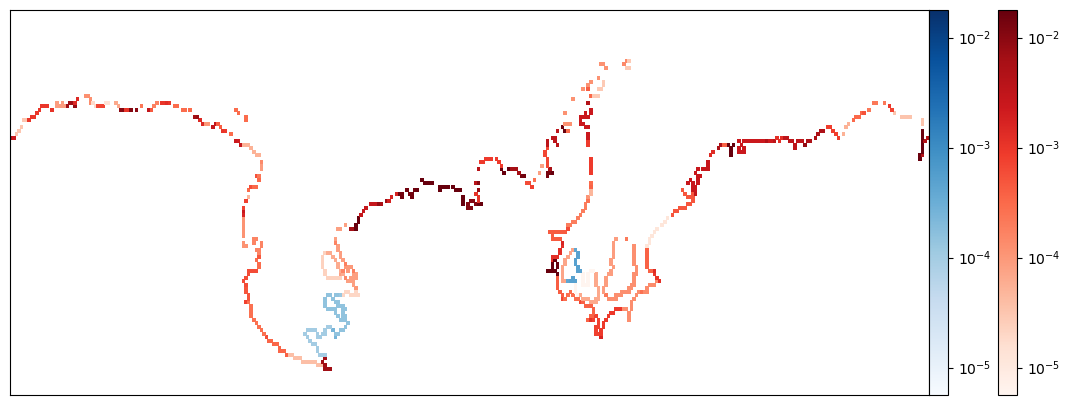

In [26]:
melt = xr.open_dataset(filepath_this_nn_output)# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')